In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


Ganti dengan path ke folder tempat Anda menyimpan file CSV
ika file berada di folder yang sama dengan skrip, biarkan kosong ""

In [7]:
DATA_DIR = "../dataset/"

Mengatur gaya plot untuk visualisasi yang lebih baik

In [8]:
sns.set(style="whitegrid")

--- Memuat Semua Dataset --- <br>
Memuat setiap file CSV ke dalam DataFrame pandas. <br>
Menambahkan penanganan error jika file tidak ditemukan. <br>

In [9]:
try:
    print("Memuat dataset...")
    member_df = pd.read_csv(os.path.join(DATA_DIR, 'member_data.csv'))
    prodgram_df = pd.read_csv(os.path.join(DATA_DIR, 'prodgram_data.csv'))
    product_df = pd.read_csv(os.path.join(DATA_DIR, 'product_data.csv'))
    train_transaction_df = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction_data.csv'))
    test_transaction_df = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction_data.csv'))
    train_label_df = pd.read_csv(os.path.join(DATA_DIR, 'train_label_data.csv'))
    print("Semua dataset berhasil dimuat.")
except FileNotFoundError as e:
    print(f"Error: File tidak ditemukan. Pastikan file CSV berada di direktori yang benar.")
    print(e)
    # Keluar dari skrip jika file tidak ada
    exit()

Memuat dataset...
Semua dataset berhasil dimuat.


Menampilkan nama kolom untuk debugging sebelum merge

In [10]:
print("\nNama kolom di product_df:", product_df.columns.tolist())
print("Nama kolom di prodgram_df:", prodgram_df.columns.tolist())


Nama kolom di product_df: ['productID', 'ProductName', 'ProductCategory', 'ProductLevel']
Nama kolom di prodgram_df: ['prodgramID', 'GrammageName', 'Point', 'Price']


--- Proses Penggabungan (Merge) --- 

In [11]:
def find_col_name(df, expected_name):
    """Mencari nama kolom yang cocok tanpa memperhatikan huruf besar/kecil."""
    for col in df.columns:
        if col.lower() == expected_name.lower():
            return col
    return None

In [12]:
fk_product_id_actual = find_col_name(train_transaction_df, 'FK_PRODUCT_ID')
product_id_actual = find_col_name(product_df, 'ProductID')

if not all([fk_product_id_actual, product_id_actual]):
    print("ERROR: Kolom kunci 'FK_PRODUCT_ID' atau 'ProductID' tidak dapat ditemukan.")
    exit()

In [17]:
# Membuat fungsi untuk menggabungkan data transaksi
def merge_transaction_data(transaction_df, member_df, product_full_df):
    """
    Fungsi untuk menggabungkan data transaksi dengan data member dan produk.
    """
    merged_df = pd.merge(transaction_df, member_df, on='MemberID', how='left')
    merged_df = pd.merge(merged_df, product_full_df, left_on=fk_product_id_actual, right_on=product_id_actual, how='left')
    return merged_df

In [18]:
# Gabungkan data transaksi latih (train) dan uji (test)
print("\nMenggabungkan data transaksi...")
# Langsung menggunakan product_df karena penggabungan dengan prodgram dilewati
train_merged_df = merge_transaction_data(train_transaction_df, member_df, product_df)
test_final_df = merge_transaction_data(test_transaction_df, member_df, product_df)


Menggabungkan data transaksi...


In [19]:
# Gabungkan data latih dengan labelnya
train_final_df = pd.merge(train_merged_df, train_label_df, on='MemberID', how='left')
print("Ukuran data latih akhir:", train_final_df.shape)
print("Ukuran data uji akhir:", test_final_df.shape)

Ukuran data latih akhir: (130854, 19)
Ukuran data uji akhir: (21098, 18)


In [20]:
# --- Konversi Tipe Data Tanggal ---
# Mengonversi kolom yang seharusnya bertipe tanggal
date_columns = ['JoinDate', 'DateOfBirth', 'YoungestKidDOB', 'EldestKidDOB', 'TransactionDateTime']
for col in date_columns:
    if col in train_final_df.columns:
        train_final_df[col] = pd.to_datetime(train_final_df[col], errors='coerce')
    if col in test_final_df.columns:
        test_final_df[col] = pd.to_datetime(test_final_df[col], errors='coerce')
print("\nKolom tanggal telah dikonversi.")


Kolom tanggal telah dikonversi.


--- Analisis Data Eksploratif (EDA) pada Data Latih ---

In [21]:
# 1. Ringkasan Statistik
print("\nRingkasan statistik untuk fitur numerik:")
print(train_final_df.describe())


Ringkasan statistik untuk fitur numerik:
       FK_PRODUCT_ID  FK_PROD_GRAM_ID            Qty  PricePerUnit  \
count  130854.000000    130854.000000  130854.000000  1.116810e+05   
mean       23.914385        43.918818       1.353745  2.173674e+05   
min        22.000000        39.000000       1.000000  3.400000e+04   
25%        22.000000        39.000000       1.000000  1.560000e+05   
50%        22.000000        39.000000       1.000000  2.650000e+05   
75%        27.000000        52.000000       1.000000  2.789000e+05   
max        53.000000        52.000000      33.000000  2.625000e+06   
std         2.310756         5.954632       0.918298  7.551674e+04   

                            JoinDate                    DateOfBirth  \
count                         130854                           6692   
mean   2020-02-04 04:33:03.474712576  2007-06-28 10:23:22.988643072   
min              1900-01-02 00:00:00            1900-01-01 00:00:00   
25%              2019-09-17 00:00:00       

In [22]:
# 2. Analisis Nilai yang Hilang (Missing Values)
print("\nPersentase nilai yang hilang per kolom:")
missing_percentage = train_final_df.isnull().sum() / len(train_final_df) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


Persentase nilai yang hilang per kolom:
DateOfBirth     94.885903
PricePerUnit    14.652208
dtype: float64


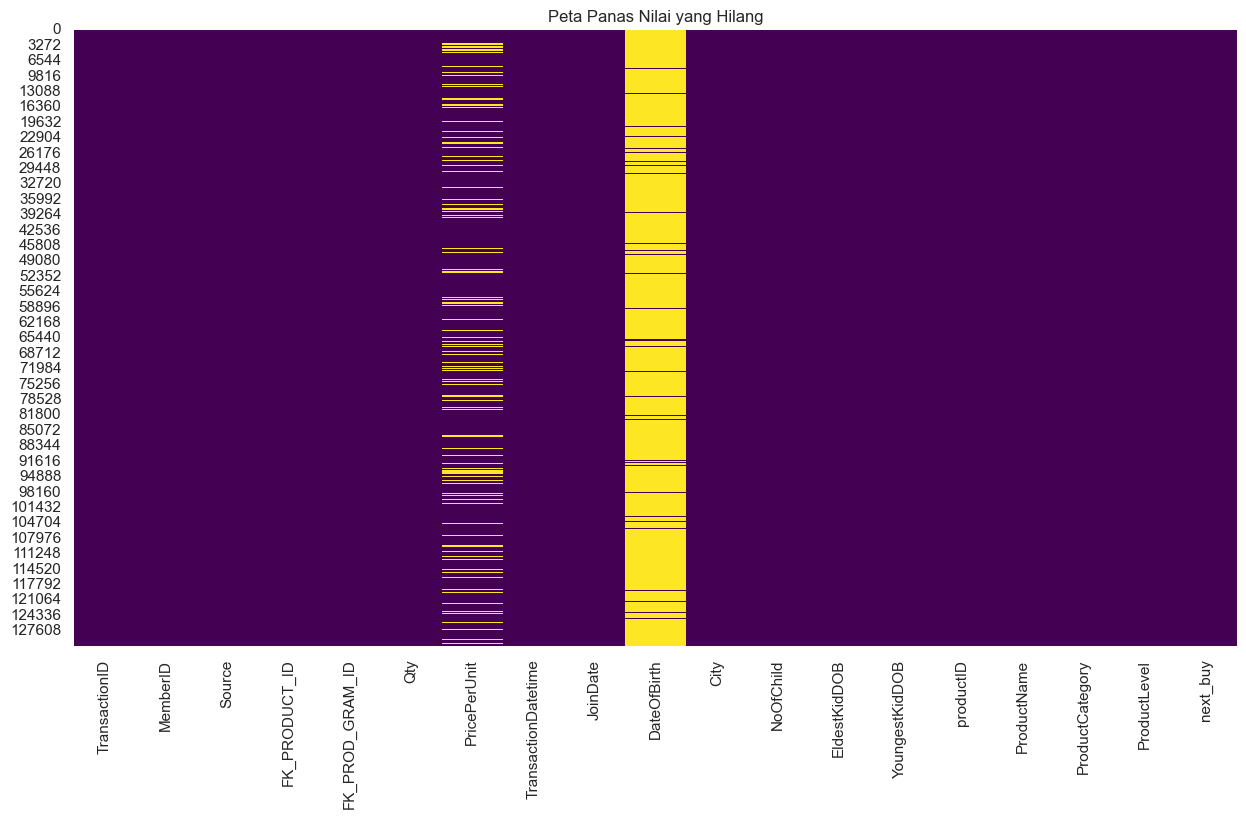

In [23]:
# Visualisasi nilai yang hilang
plt.figure(figsize=(15, 8))
sns.heatmap(train_final_df.isnull(), cbar=False, cmap='viridis')
plt.title('Peta Panas Nilai yang Hilang')
plt.show()

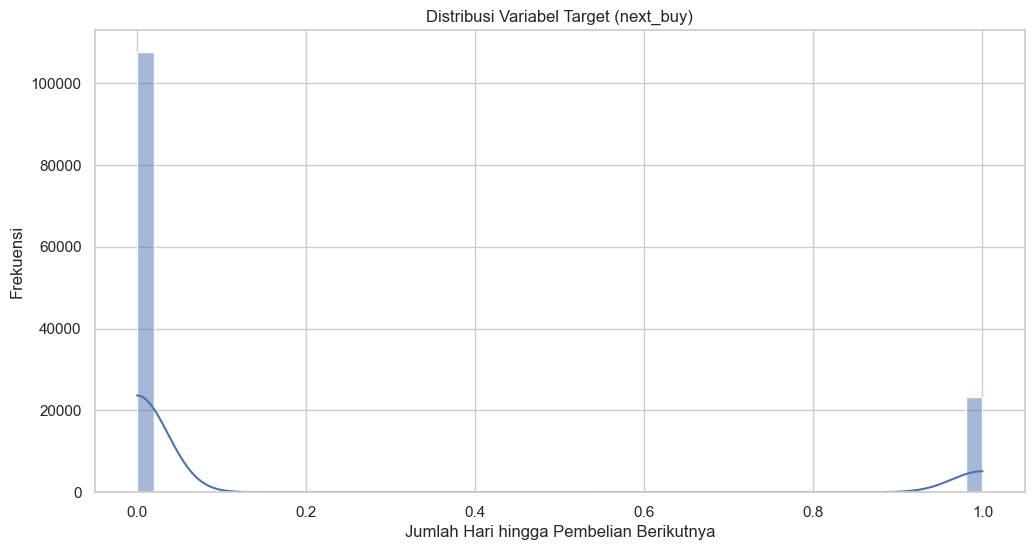

In [24]:
# 3. Analisis Variabel Target ('next_buy')
plt.figure(figsize=(12, 6))
# Memastikan tidak ada nilai NaN sebelum plotting
next_buy_data = train_final_df['next_buy'].dropna()
if not next_buy_data.empty:
    sns.histplot(next_buy_data, kde=True, bins=50)
    plt.title('Distribusi Variabel Target (next_buy)')
    plt.xlabel('Jumlah Hari hingga Pembelian Berikutnya')
    plt.ylabel('Frekuensi')
    plt.show()
else:
    print("Tidak ada data 'next_buy' yang valid untuk diplot.")


Analisis fitur kategorikal utama:


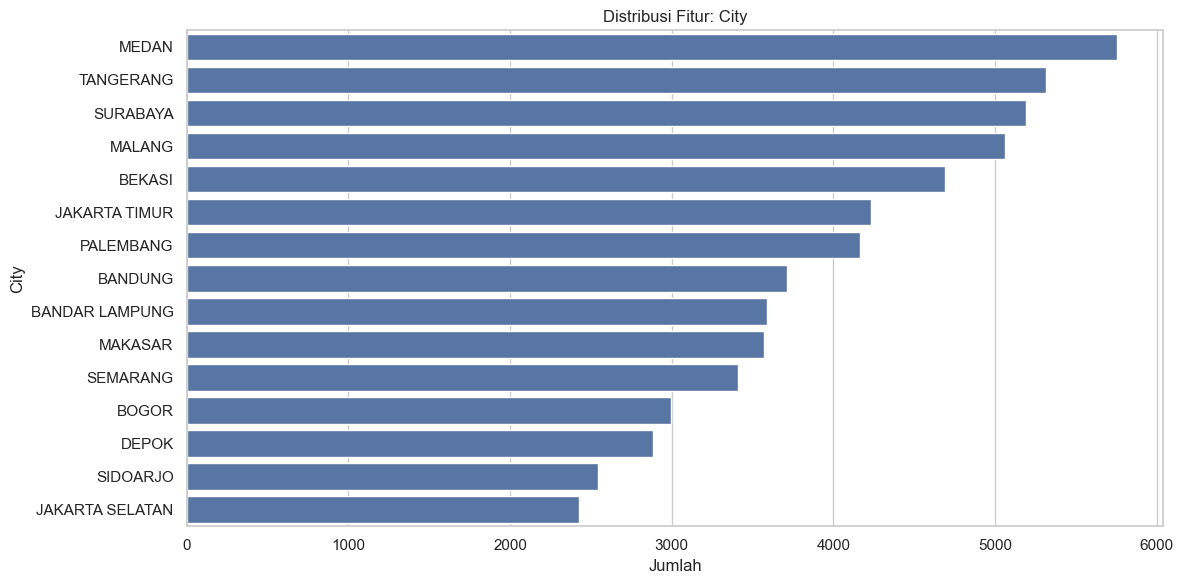

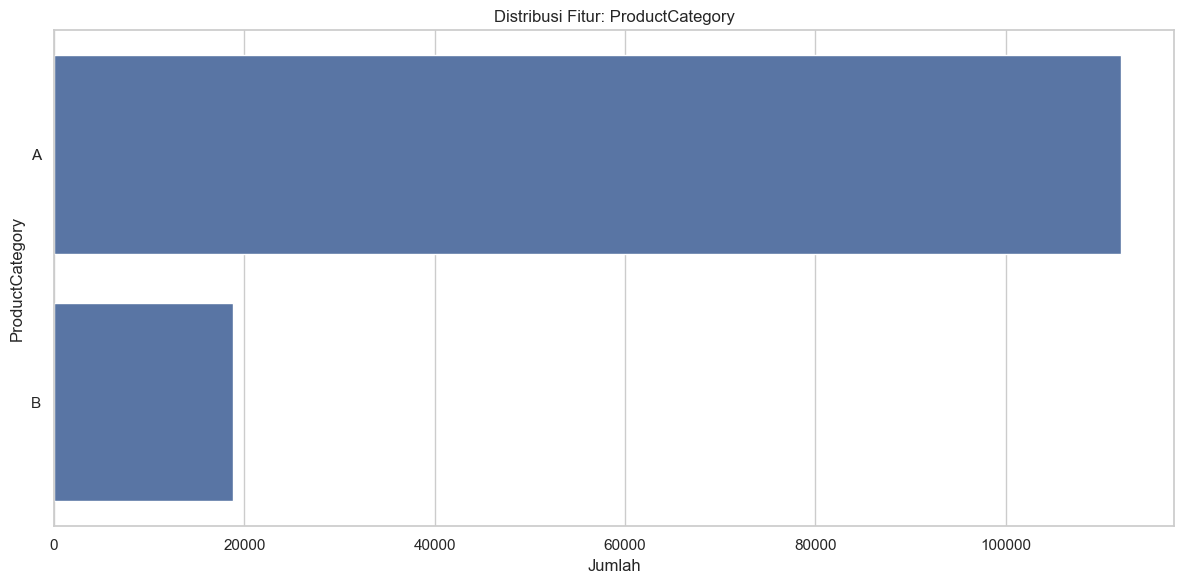

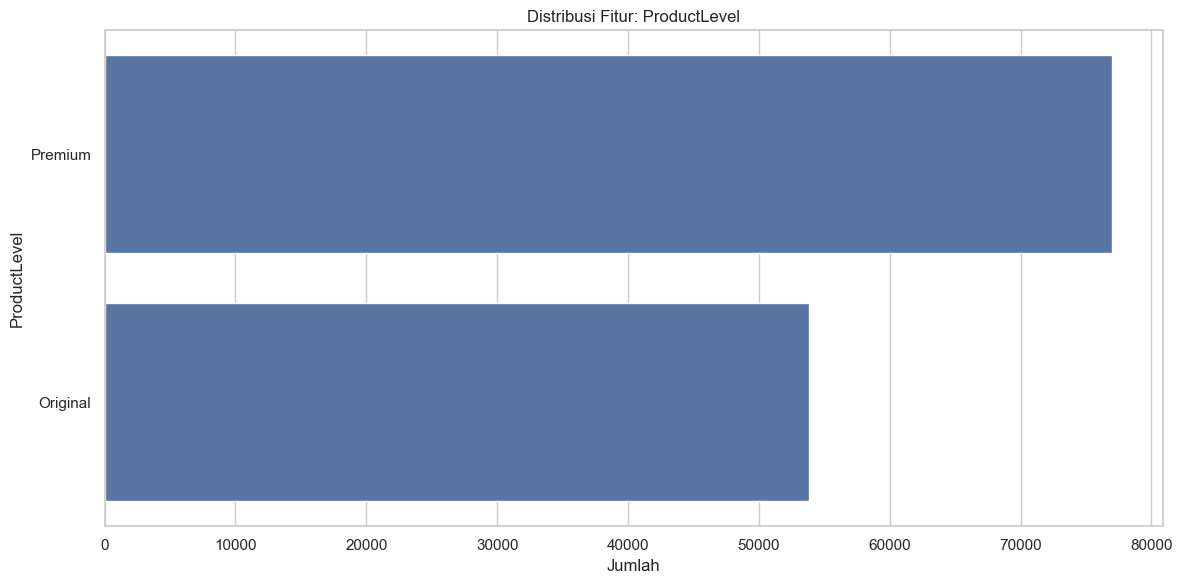

In [25]:
# 4. Analisis Fitur Kategorikal
print("\nAnalisis fitur kategorikal utama:")
# 'GrammageName' dihapus karena data prodgram tidak bisa digabungkan
categorical_features = ['City', 'ProductCategory', 'ProductLevel'] 
for feature in categorical_features:
    if feature in train_final_df.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(y=train_final_df[feature], order=train_final_df[feature].value_counts().index[:15])
        plt.title(f'Distribusi Fitur: {feature}')
        plt.xlabel('Jumlah')
        plt.ylabel(feature)
        plt.tight_layout()
        plt.show()

In [27]:
# 5. Analisis Fitur Numerik
numerical_features = train_final_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nFitur numerik yang diidentifikasi: {numerical_features}")


Fitur numerik yang diidentifikasi: ['FK_PRODUCT_ID', 'FK_PROD_GRAM_ID', 'Qty', 'PricePerUnit', 'NoOfChild', 'productID', 'next_buy']


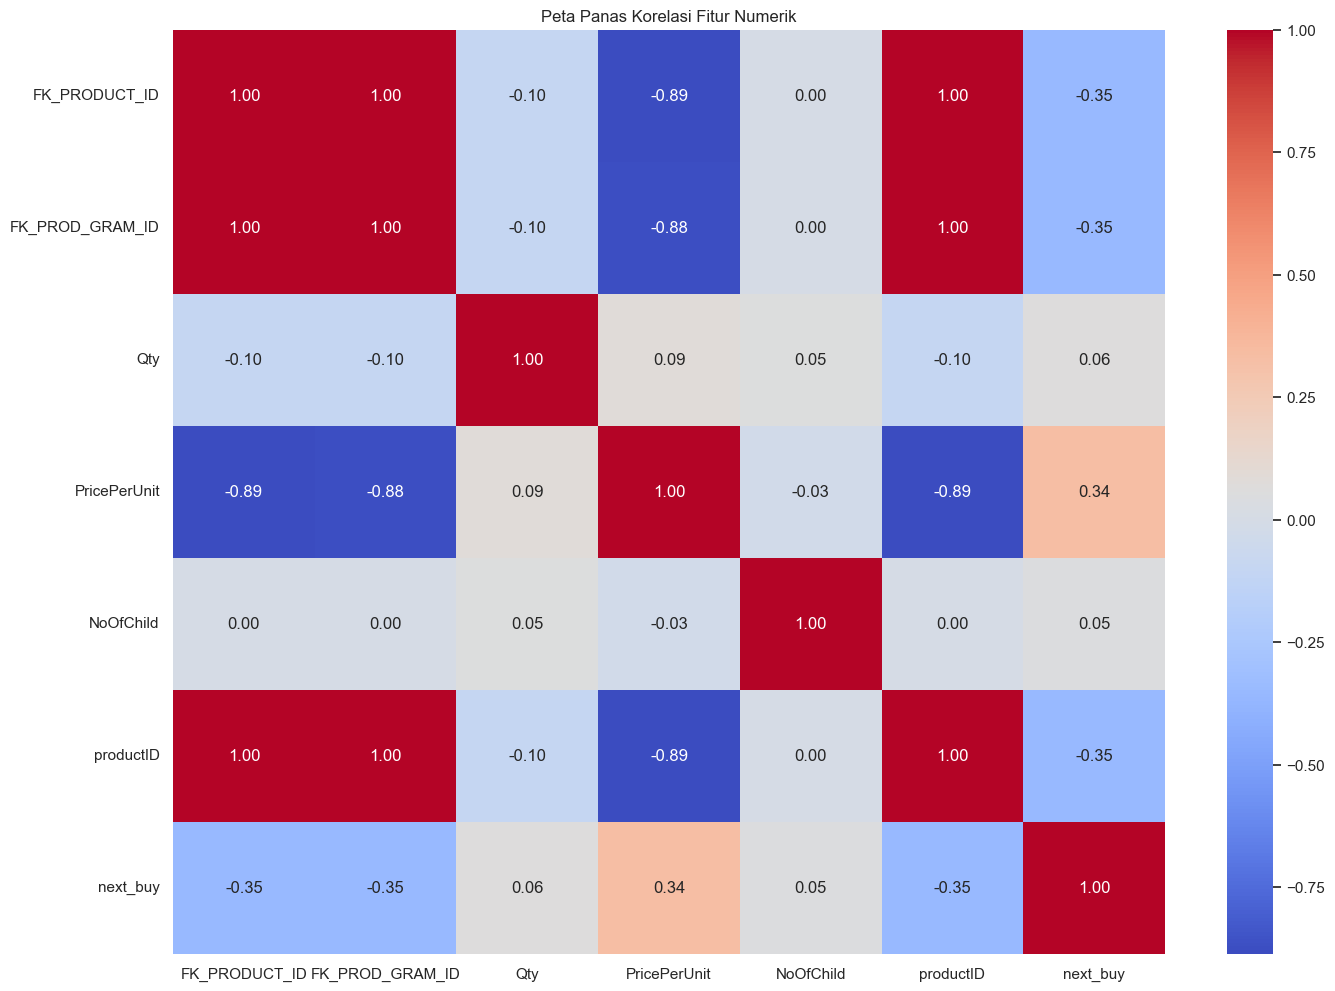

In [28]:
# 6. Peta Panas Korelasi
# Hanya menyertakan kolom numerik untuk korelasi
plt.figure(figsize=(16, 12))
correlation_matrix = train_final_df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Peta Panas Korelasi Fitur Numerik')
plt.show()

In [29]:
print(train_final_df.head())

                              TransactionID                          MemberID  \
0  ffd6c035bef03a2c386caf2552148fb2402b0b24  7ef72aa51aecb701dc5c4074480fcdf6   
1  4fadf10aff7e250cc8d63badeaefdf383c0e1c13  577f1b9a093c2cec6398b1118f5d99ab   
2  7299df1aaf47b52017f58dd8e59df1fe37072670  e2ee74f248a74ed886a22f14348fbafd   
3  22dae0e1e8bb87601eabd712721bd249739bc620  cefa8ef7469a8b4e6df3f745d4905000   
4  6a744d5d79e09b0c1646e604db1c4ec65eff73d7  5eecda17ddf06ed9d79f298b13f84785   

      Source  FK_PRODUCT_ID  FK_PROD_GRAM_ID  Qty  PricePerUnit  \
0      ELANG             27               52    1           NaN   
1   ALFAMART             22               39    1      290000.0   
2     EKTONG             22               39    1      263500.0   
3      CITRA             27               52    3      145000.0   
4  INDOMARET             27               52    1      165900.0   

       TransactionDatetime   JoinDate DateOfBirth      City  NoOfChild  \
0  2020-07-01 07:41:00 UTC 2019-12-2

In [33]:
print(test_final_df.head())

                              TransactionID                          MemberID  \
0  5f57263c9b0b2b3e3d7c404510dd59060999115a  c2a630e3d0dc77dac0f63424a9ae1438   
1  b0c438ae346e794fef83c63a9ce17d6df73da233  3ecf7484c08418953e967a20de37051b   
2  7e2498fc518f0b1489982848a29dc2677ec31367  97bbd6c99a862f20657d9b2b1c77b2c8   
3  aaa52daf4ca3b8befcbe01362d8219f67293bf45  3ce072ff9c6f2f4b7c95dbc08324a24d   
4  4ec62459fb8d83062284e32f3c7b5af125d242b1  ab0b0de2a1c85a40b5d58644aef745c0   

      Source  FK_PRODUCT_ID  FK_PROD_GRAM_ID  Qty  PricePerUnit  \
0   ALFAMART             27               52    1      165300.0   
1   ALFAMART             27               52    1      165300.0   
2   ALFAMART             27               52    1      165300.0   
3  INDOMARET             26               49    1           NaN   
4   ALFAMART             26               49    2       85500.0   

       TransactionDatetime   JoinDate DateOfBirth       City  NoOfChild  \
0  2020-07-01 06:09:00 UTC 2019-12-